In [147]:
import shutil
import random
from pathlib import Path
from typing import Literal

PoisonSource = Literal["glasses", "beard"]
Split = Literal["train", "test", "both"]

def create_single_class_replaced_dataset_mixed_from_all_classes(
    yale_root: str,
    poison_rate: float,
    target_class: str,  # z.B. "01" .. "15"
    poison_source: PoisonSource = "glasses",
    split: Split = "train",
    seed: int = 42,
    out_parent: str | None = None,
    write_mapping_csv: bool = True,
    include_target_class_poisons: bool = True,
    allow_reuse_if_pool_too_small: bool = True,
) -> str:
    """
    Output:
      <out_parent>/Yale_<rate>/poisoned_<source>_replaced_singleclass_<target_class>_mixall

    Ablauf:
    1) Alle Klassen werden zunächst original kopiert.
    2) Nur in target_class werden k = round(poison_rate * #originals_in_target) Bilder ersetzt.
       Die Ersatzbilder (poisons) werden aus einem Pool genommen, der Poison-Bilder aus ALLEN Klassen enthält
       (optional inkl. target_class).

    Wichtig:
    - Die Dateinamen in target_class bleiben die Originalnamen.
    - Andere Klassen bleiben unverändert (original).
    """

    if not (0.0 <= poison_rate <= 1.0):
        raise ValueError("poison_rate must be between 0.0 and 1.0")

    random.seed(seed)
    in_root = Path(yale_root)
    if not in_root.exists():
        raise FileNotFoundError(f"yale_root not found: {in_root}")

    rate_str = f"{poison_rate:.3f}".rstrip("0").rstrip(".")
    out_parent_path = Path(out_parent) if out_parent else in_root.parent
    out_root = (
        out_parent_path
        / f"Yale_{rate_str}"
        / f"poisoned_{poison_source}_replaced_singleclass_{target_class}_mixall"
    )

    if out_root.exists():
        raise FileExistsError(f"Output folder already exists: {out_root}")
    out_root.mkdir(parents=True, exist_ok=False)

    def list_pngs(folder: Path) -> list[Path]:
        if not folder.exists():
            return []
        return sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() == ".png"])

    mapping_rows = []  # split,target_class,target_idx,target_filename,poison_class,poison_filename,replaced

    def build_one_split(split_suffix: str, out_split_name: str) -> int:
        original_base = in_root / f"original_{split_suffix}"
        poison_base = in_root / f"{poison_source}_{split_suffix}"

        if not original_base.exists():
            raise FileNotFoundError(f"Missing folder: {original_base}")
        if not poison_base.exists():
            raise FileNotFoundError(f"Missing folder: {poison_base}")

        class_dirs = sorted([p for p in original_base.iterdir() if p.is_dir()], key=lambda p: p.name)
        if not class_dirs:
            raise RuntimeError(f"No class subfolders found in {original_base}")

        out_split_dir = out_root / out_split_name
        out_split_dir.mkdir(parents=True, exist_ok=True)

        # 1) Alles original kopieren
        for cls_dir in class_dirs:
            originals = list_pngs(cls_dir)
            if not originals:
                continue
            out_cls = out_split_dir / cls_dir.name
            out_cls.mkdir(parents=True, exist_ok=True)
            for o in originals:
                shutil.copy2(o, out_cls / o.name)

        # 2) Targetklasse ersetzen
        target_original_dir = original_base / target_class
        if not target_original_dir.exists():
            raise RuntimeError(f"Target class {target_class} not found in {target_original_dir}")

        target_originals = list_pngs(target_original_dir)
        if not target_originals:
            return 0

        k = int(round(poison_rate * len(target_originals)))
        if k <= 0:
            return 0

        # Poison-Pool aus ALLEN Klassen zusammenbauen
        poison_pool: list[tuple[str, Path]] = []
        poison_class_dirs = sorted([p for p in poison_base.iterdir() if p.is_dir()], key=lambda p: p.name)

        for pcls in poison_class_dirs:
            if (not include_target_class_poisons) and (pcls.name == target_class):
                continue
            for img in list_pngs(pcls):
                poison_pool.append((pcls.name, img))

        if not poison_pool:
            raise RuntimeError(f"No poison images found in {poison_base} (pool is empty).")

        # Indizes in target_class wählen, die ersetzt werden
        chosen_target_idx = random.sample(range(len(target_originals)), k)

        # Poison-Auswahl: ohne Wiederverwendung wenn möglich, sonst optional mit Wiederverwendung
        if k <= len(poison_pool):
            chosen_poisons = random.sample(poison_pool, k)
        else:
            if not allow_reuse_if_pool_too_small:
                raise RuntimeError(
                    f"Need {k} poison images but pool has only {len(poison_pool)}. "
                    "Set allow_reuse_if_pool_too_small=True to allow reuse."
                )
            chosen_poisons = [random.choice(poison_pool) for _ in range(k)]

        out_target_dir = out_split_dir / target_class
        replaced = 0

        # Ersetzen: i-te Auswahl überschreibt das target_originals[idx] mit einem poison
        for idx, (poison_cls, poison_img) in zip(sorted(chosen_target_idx), chosen_poisons):
            dst_name = target_originals[idx].name
            dst_path = out_target_dir / dst_name
            shutil.copy2(poison_img, dst_path)
            replaced += 1
            mapping_rows.append(
                (out_split_name, target_class, idx, dst_name, poison_cls, poison_img.name, True)
            )

        return replaced

    replaced_total = 0
    if split in ("train", "both"):
        replaced_total += build_one_split("extended", "train")
    if split in ("test", "both"):
        replaced_total += build_one_split("test_extended", "test")

    if write_mapping_csv:
        csv_path = out_root / "mapping.csv"
        with open(csv_path, "w", encoding="utf-8") as f:
            f.write("split,target_class,target_idx,target_filename,poison_class,poison_filename,replaced\n")
            for row in mapping_rows:
                f.write(",".join(map(str, row)) + "\n")

    print(f"DONE. Replaced images in target class {target_class}: {replaced_total}")
    print("Output folder:", out_root)
    if write_mapping_csv:
        print("Mapping file :", out_root / "mapping.csv")

    return str(out_root)

## Creating new poisoned Dataset 

In [148]:
from pathlib import Path


root = Path(r"C:\Users\JakobOlsacher\Documents\Repos\184.702_MachineLearning\Ex3\Yale")


create_single_class_replaced_dataset_mixed_from_all_classes(
    yale_root=str(root),
    poison_rate=0.1,     # 10% der Targetklasse werden poisoned
    target_class="07",
    poison_source="glasses",
    split="both",
    seed=42,
    include_target_class_poisons=False,   # poisons aus Klasse 07 dürfen auch rein
)

print("Created:", out_path)

DONE. Replaced images in target class 07: 11
Output folder: C:\Users\JakobOlsacher\Documents\Repos\184.702_MachineLearning\Ex3\Yale_0.1\poisoned_glasses_replaced_singleclass_07_mixall
Mapping file : C:\Users\JakobOlsacher\Documents\Repos\184.702_MachineLearning\Ex3\Yale_0.1\poisoned_glasses_replaced_singleclass_07_mixall\mapping.csv
Created: C:\Users\JakobOlsacher\Documents\Repos\184.702_MachineLearning\Ex3\Yale_0.5\poisoned_beard_replaced


## Train AutoEncoder

Import AutoEncoderDEfense

In [149]:
#import AutoendoderDefense
import sys
from pathlib import Path

# Notebook liegt in .../Ex3/
PROJECT_ROOT = Path.cwd().resolve().parents[0]   # eine Ebene hoch = Repo Root
# Falls du das Notebook aus einem anderen Working Directory startest:
# PROJECT_ROOT = Path(__file__).resolve().parents[1]  # klappt in .py, nicht in ipynb

sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("BackdoorBox exists:", (PROJECT_ROOT / "BackdoorBox").exists())




from BackdoorBox.core.defenses import AutoEncoderDefense

Project root: C:\Users\JakobOlsacher\Documents\Repos\184.702_MachineLearning
BackdoorBox exists: True


Load Original Data

In [150]:
from pathlib import Path
from torchvision import datasets, transforms

data_root = Path(r"C:\Users\JakobOlsacher\Documents\Repos\184.702_MachineLearning\Ex3\Yale")

train_dir = data_root / "original_extended"
test_dir  = data_root / "original_test_extended"  # falls vorhanden

transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(str(train_dir), transform=transform)
test_dataset  = datasets.ImageFolder(str(test_dir),  transform=transform)

print("Train:", len(train_dataset), "Test:", len(test_dataset))
print("Classes:", len(train_dataset.classes))


Train: 1350 Test: 300
Classes: 15


Train AutoEncoder

In [151]:
from torch.utils.data import random_split

n = len(train_dataset)
n_test = int(0.1 * n)
n_train = n - n_test
train_dataset, test_dataset = random_split(train_dataset, [n_train, n_test])
print("Train:", len(train_dataset), "Test:", len(test_dataset))

Train: 1215 Test: 135


In [152]:
import torch
import torch.nn as nn

class DenoisingWrapper(nn.Module):
    def __init__(self, model, noise_factor=0.2):
        super(DenoisingWrapper, self).__init__()
        self.model = model
        self.noise_factor = noise_factor

    def forward(self, x):
        if self.training:
            # Rauschen erzeugen
            noise = torch.randn_like(x) * self.noise_factor
            # Rauschen auf das Bild addieren
            x_noisy = x + noise
            # Werte wieder auf den gültigen Bereich 0-1 beschränken
            x_noisy = torch.clamp(x_noisy, 0., 1.)
            return self.model(x_noisy)
        else:
            # Im Testmodus kein Rauschen hinzufügen!
            return self.model(x)


class ConvAE(nn.Module):
    def __init__(self):
        super(ConvAE, self).__init__()
        
        # Encoder: Bessere Aktivierungsfunktionen (LeakyReLU) + Batch Normalization
        self.enc = nn.Sequential(
            # Input: 1 x 64 x 64 -> 32 x 32 x 32
            nn.Conv2d(1, 32, 3, stride=2, padding=1), 
            nn.BatchNorm2d(32), 
            nn.LeakyReLU(0.2, inplace=True),
            
            # 32 x 32 x 32 -> 64 x 16 x 16
            nn.Conv2d(32, 64, 3, stride=2, padding=1), 
            nn.BatchNorm2d(64), 
            nn.LeakyReLU(0.2, inplace=True),
            
            # 64 x 16 x 16 -> 128 x 8 x 8
            nn.Conv2d(64, 128, 3, stride=2, padding=1), 
            nn.BatchNorm2d(128), 
            nn.LeakyReLU(0.2, inplace=True),
        )

        # Decoder
        self.dec = nn.Sequential(
            # 128 x 8 x 8 -> 64 x 16 x 16
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), 
            nn.BatchNorm2d(64), 
            nn.ReLU(inplace=True),
            
            # 64 x 16 x 16 -> 32 x 32 x 32
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), 
            nn.BatchNorm2d(32), 
            nn.ReLU(inplace=True),
            
            # 32 x 32 x 32 -> 1 x 64 x 64
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1),
            nn.Sigmoid()  # Output zwischen 0 und 1
        )

    def forward(self, x):
        return self.dec(self.enc(x))
    
# basis_ae = ConvAE()    

# autoencoder = DenoisingWrapper(basis_ae, noise_factor=0.05)

autoencoder = ConvAE()

In [153]:
from BackdoorBox.core.defenses import AutoEncoderDefense

aed = AutoEncoderDefense(autoencoder=autoencoder, pretrain=None, seed=1, deterministic=False)

In [154]:
schedule = {
    "device": "GPU",              # "CPU" oder weglassen für CPU
    "GPU_num": 1,
    # "CUDA_VISIBLE_DEVICES": "0",

    "batch_size": 16,
    # Windows/Jupyter: num_workers>0 crasht häufig wegen multiprocessing/spawn
    "num_workers": 0,

    "lr": 1e-3,
    "betas": (0.9, 0.999),
    "eps": 1e-8,
    "weight_decay": 0.0,
    "amsgrad": False,

    "epochs": 40,
    "schedule": [25, 35],         # bei epoch 25 und 35 lr *= gamma
    "gamma": 0.1,

    "log_iteration_interval": 50,
    "test_epoch_interval": 1,
    "save_epoch_interval": 5,

    "save_dir": str(data_root / "experiments"),
    "experiment_name": "yale_autoencoder_clean"
}

In [155]:
aed.train_autoencoder(train_dataset, test_dataset, schedule)

This machine has 1 cuda devices, and use 1 of them to train.
Total train samples: 1215
Total test samples: 135
Batch size: 16
iteration every epoch: 75
Initial learning rate: 0.001

[2026-02-04_11:49:42] Epoch:1/40, iteration:50/75, lr: 0.001, loss: 0.39770305156707764, time: 7.633007526397705

==========Test result on test dataset==========
[2026-02-04_11:49:47] loss: 0.36678317189216614, time: 5.182840824127197

[2026-02-04_11:49:48] Epoch:2/40, iteration:24/75, lr: 0.001, loss: 0.37409454584121704, time: 5.7445902824401855

[2026-02-04_11:49:49] Epoch:2/40, iteration:74/75, lr: 0.001, loss: 0.3284193277359009, time: 1.172579288482666

==========Test result on test dataset==========
[2026-02-04_11:49:49] loss: 0.3636840581893921, time: 0.24517512321472168

[2026-02-04_11:49:50] Epoch:3/40, iteration:48/75, lr: 0.001, loss: 0.3343350291252136, time: 1.382704257965088

==========Test result on test dataset==========
[2026-02-04_11:49:51] loss: 0.3591117262840271, time: 0.83636116981506

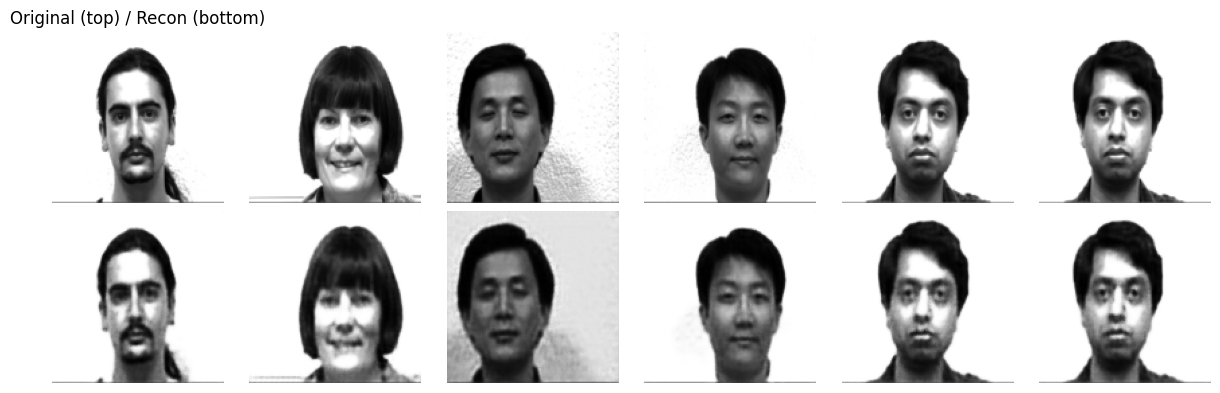

In [156]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
aed.autoencoder = aed.autoencoder.to(device)
aed.autoencoder.eval()

loader = DataLoader(test_dataset, batch_size=8, shuffle=True)

x, _ = next(iter(loader))
x = x.to(device)

with torch.no_grad():
    x_rec = aed.preprocess(x)

# plot first 6
x_cpu = x.detach().cpu()
r_cpu = x_rec.detach().cpu()

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i in range(6):
    axes[0, i].imshow(x_cpu[i].squeeze(0), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(r_cpu[i].squeeze(0), cmap="gray")
    axes[1, i].axis("off")
axes[0,0].set_title("Original (top) / Recon (bottom)")
plt.tight_layout()
plt.show()

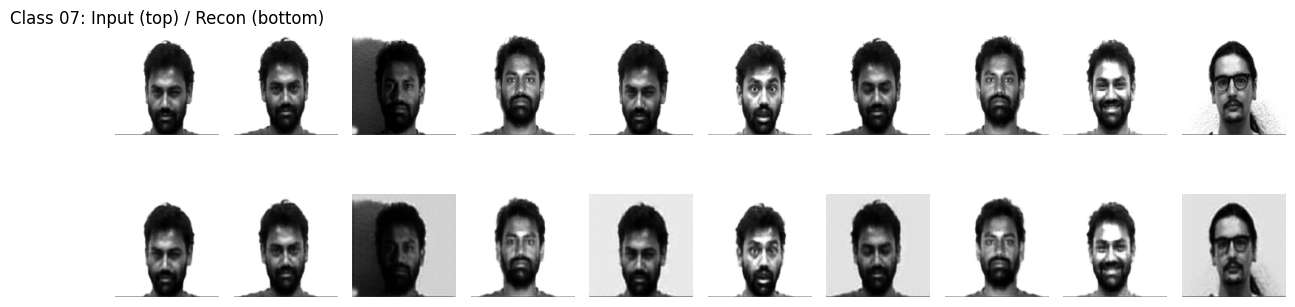

In [159]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import torch, matplotlib.pyplot as plt
from pathlib import Path

data_root = Path(r"C:\Users\JakobOlsacher\Documents\Repos\184.702_MachineLearning\Ex3\Yale_0.1\poisoned_glasses_replaced_singleclass_07_mixall")
poison_dir = data_root / "train"  # oder "test"

transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

ds = datasets.ImageFolder(str(poison_dir), transform=transform)

# Foldername der Targetklasse
target_class = "07"

# Welcher Klassenindex gehört zu "07"?
target_idx = ds.class_to_idx[target_class]

# Indizes aller Samples aus Klasse "07"
only_target_indices = [i for i, (_, y) in enumerate(ds.samples) if y == target_idx]

# Dataset nur für Klasse "07"
ds_07 = Subset(ds, only_target_indices)

loader_07 = DataLoader(ds_07, batch_size=10, shuffle=True)

x, _ = next(iter(loader_07))
x = x.to(device)

with torch.no_grad():
    xr = aed.preprocess(x)

x_cpu = x.detach().cpu()
r_cpu = xr.detach().cpu()

fig, axes = plt.subplots(2, 10, figsize=(12, 4))
for i in range(min(10, x_cpu.size(0))):
    axes[0, i].imshow(x_cpu[i].squeeze(0), cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(r_cpu[i].squeeze(0), cmap="gray"); axes[1, i].axis("off")

axes[0, 0].set_title("Class 07: Input (top) / Recon (bottom)")
plt.tight_layout(); plt.show()

In [98]:
from torch.utils.data import DataLoader
import torch.nn.functional as F

def calculate_average_loss(model, dataset, device="cuda", batch_size=64):
    model.eval()
    model.to(device)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    total_loss = 0.0
    num_batches = 0
    
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            outputs = model(images)
            # MSE Loss berechnen
            loss = F.mse_loss(outputs, images)
            total_loss += loss.item()
            num_batches += 1
            
    avg_loss = total_loss / num_batches
    print(f"Durchschnittlicher MSE Loss auf dem Testset: {avg_loss:.6f}")
    return avg_loss

# Berechnung starten
calculate_average_loss(autoencoder, test_dataset)

Durchschnittlicher MSE Loss auf dem Testset: 0.001049


0.001049363558801512